# Utils

In [1]:
import os 
import pandas as pd
from datetime import datetime

RESULTS_FILE = "model_results_log.csv"

# generated by chatgpt
def log_result(
    model_name,
    params,
    mean_score,
    std_score=None,
    notes=None
):
    """
    Append a single experiment result to a CSV log.
    """
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "params": str(params),
        "mean_f1_macro": mean_score,
        "std_f1_macro": std_score,
        "notes": notes
    }

    df_row = pd.DataFrame([row])

    if os.path.exists(RESULTS_FILE):
        df_row.to_csv(RESULTS_FILE, mode="a", header=False, index=False)
    else:
        df_row.to_csv(RESULTS_FILE, mode="w", header=True, index=False)

    print(f"✔ Logged result for {model_name}")

# 1 Cleaning Data

#### NOTE: We will not load test data here yet to prevent any accidental leakage

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("../dataset/diabetic_data_training.csv")

ids_mapping = pd.read_csv("../dataset/IDS_mapping.csv")

print("training data shape:", train_df.shape)
print("IDS mapping shape:", ids_mapping.shape)

print("training data")
display(train_df.head())

print("ids mapping")
display(ids_mapping.head())

training data shape: (91589, 50)
IDS mapping shape: (67, 2)
training data


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


ids mapping


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


## 1.1 Checking Target Distribution Balance

#### Note: If target distribution not balanced, for example 90% of people readmitted = "NO", the model might just learn to classify everybody as NO and have 90% accuraccy, which would be very bad

In [3]:
less_than_30 = 0
more_than_30 = 0
not_readmitted = 0
for _, row in train_df.iterrows():
    if row["readmitted"] == "NO":
        not_readmitted += 1
    elif row["readmitted"] == ">30":
        more_than_30 += 1
    else:
        less_than_30 += 1
print("<30:", less_than_30)
print(">30:", more_than_30)
print("NO:", not_readmitted)

<30: 10245
>30: 31989
NO: 49355


#### This means we an have uneven split of 1 : 3 : 5 and we have moderate class imbalance. This means we must be careful to make a balanced train - validation split. Also, when testing the performance of models, we must make sure to check for recall of the "<30" class to see if the model is catching that.

## 1.2. Train - Validation Split

#### We use the stratify option to ensure that the target variable distributions are the same in the train and val sets. We will use k-folds so nothing becessary to be done here yet

## 1.3. Missing Values

#### Some columns have a lot of values missing. For those, with missing values >70%, we could drop them as they are likely noise (and we can't really fill the values in with median / mode). However, what could potentially better is that we use a binary if that specific thing is relevnt or not (e.g., certain value might only be measured when it is relevant. So waiting for PCA to see if it is actually relevent.)

In [4]:
train_df = train_df.replace('?', np.nan)

missing_column_fraction = (train_df.isnull().sum() / len(train_df))

very_high_missing = missing_column_fraction[missing_column_fraction > 0.7].index.tolist()
high_missing = missing_column_fraction[(missing_column_fraction > 0.2) & (missing_column_fraction <= 0.7)].index.tolist()
low_missing = missing_column_fraction[(missing_column_fraction > 0) & (missing_column_fraction <= 0.2)].index.tolist()
no_missing = missing_column_fraction[missing_column_fraction == 0].index.tolist()

print("Very high missing (>0.7)", very_high_missing)
print("High missing (0.7 > x > 0.2)", high_missing)
print("Low missing (0.2 > x > 0)", low_missing)
print("No missing", no_missing)

Very high missing (>0.7) ['weight', 'max_glu_serum', 'A1Cresult']
High missing (0.7 > x > 0.2) ['payer_code', 'medical_specialty']
Low missing (0.2 > x > 0) ['race', 'diag_1', 'diag_2', 'diag_3']
No missing ['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [5]:
# For Very High Missing we create a binary column, whether the value has been recorded or not
for col in very_high_missing:
    train_df[col] = 1 - train_df[col].isnull().astype(int)
    train_df = train_df.rename(columns={col: f"is_{col}_recorded"})


# For High Missing we can create a new class of "Unknown", we don't need to create a seperate column to flag this is weird, as it will be
# correlated
for col in high_missing:
    train_df[col] = train_df[col].fillna("Unknown")


# For Low Missing we can reaplce with a median for numerical values, mode for non-numerical. For race, mode is reasonable because there 
# aren't many options, however, for daignoses we could do a new category unknown to not distort the distribution too much. Here we
# need a flag because we tell the model - we guessed that (for race). Fir diag we don't need, same principle as for high_missing
for col in ["diag_1", "diag_2", "diag_3"]:
    train_df[col] = train_df[col].fillna("Unknown")

train_df[f'is_{col}_interpolated'] = train_df[col].isnull().astype(int)
train_df["race"] = train_df["race"].fillna(train_df["race"].mode()[0])


## 1.4. Making sense of the Data

#### We will check whether numerical values should be considered as numerical - if they should be ordered or not

In [6]:
# We can drop columns like patient_nbr, encounter_id - we can see in the feature table that they are not classified as features
train_df = train_df.drop("patient_nbr", axis=1)
train_df = train_df.drop("encounter_id", axis=1)

In [7]:
# Since age is actually an ordered column we will take the midpoint value + this should be an integer
def age_parser(age_string):
    bounds = age_string.strip("[]()").split("-")
    return (int(bounds[0]) + int(bounds[1])) // 2
train_df["age"] = train_df["age"].apply(lambda x: age_parser(x))


In [8]:
# If we check the IDS_mapping file we can see that the data in columns admission_type_id, discharge_disposition_id, admission_source_id
# shouldn't be ordered integers but strings - so we change them to strings and then do one-hot encoding
train_df["admission_type_id"] = train_df["admission_type_id"].astype(str)
train_df["admission_source_id"] = train_df["admission_source_id"].astype(str)
train_df["discharge_disposition_id"] = train_df["discharge_disposition_id"].astype(str)

In [9]:
int_cols = train_df.select_dtypes(include=['int', 'int64', 'int32']).columns.tolist()
print(int_cols)

['age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'is_max_glu_serum_recorded', 'is_A1Cresult_recorded', 'is_diag_3_interpolated']


## 1.5. Encoding into Numerical Values

#### Most models need numerical values so for columns with multiple options we can encode as binaries. However, we have to make sure we don't get an explosion of features. Hence we will use top N version of One-Hot-Encoding -> we will only do binary flags for most common N options

In [10]:
column_values = {}
for column in train_df.columns:
    unique_values = set(train_df[column])
    column_values[column] = unique_values
column_values

{'race': {'AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other'},
 'gender': {'Female', 'Male', 'Unknown/Invalid'},
 'age': {5, 15, 25, 35, 45, 55, 65, 75, 85, 95},
 'is_weight_recorded': {0, 1},
 'admission_type_id': {'1', '2', '3', '4', '5', '6', '7', '8'},
 'discharge_disposition_id': {'1',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '2',
  '20',
  '22',
  '23',
  '24',
  '25',
  '27',
  '28',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9'},
 'admission_source_id': {'1',
  '10',
  '11',
  '13',
  '14',
  '17',
  '2',
  '20',
  '22',
  '25',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9'},
 'time_in_hospital': {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14},
 'payer_code': {'BC',
  'CH',
  'CM',
  'CP',
  'DM',
  'FR',
  'HM',
  'MC',
  'MD',
  'MP',
  'OG',
  'OT',
  'PO',
  'SI',
  'SP',
  'UN',
  'Unknown',
  'WC'},
 'medical_specialty': {'AllergyandImmunology',
  'Anesthesiology',
  'Anesthesiology-Pediatric',
  'Cardiology',
  'Card

In [11]:
# We first check whether columns are actually consistent - like having a column with 99% integers, 1% unknown or something would be bad

result = []

for col in train_df.columns:
    series = train_df[col]
    total = len(series)
    numeric_count = series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and not pd.isnull(x)).sum()
    string_count = series.apply(lambda x: isinstance(x, str)).sum()

    result.append({
        'Column': col,
        'Total': total,
        'Numeric': numeric_count,
        'String': string_count,
        'Type Breakdown': f"Strings: {string_count}, Numerics: {numeric_count}"
    })

breakdown_df = pd.DataFrame(result)
print(breakdown_df)


                       Column  Total  Numeric  String  \
0                        race  91589        0   91589   
1                      gender  91589        0   91589   
2                         age  91589    91589       0   
3          is_weight_recorded  91589    91589       0   
4           admission_type_id  91589        0   91589   
5    discharge_disposition_id  91589        0   91589   
6         admission_source_id  91589        0   91589   
7            time_in_hospital  91589    91589       0   
8                  payer_code  91589        0   91589   
9           medical_specialty  91589        0   91589   
10         num_lab_procedures  91589    91589       0   
11             num_procedures  91589    91589       0   
12            num_medications  91589    91589       0   
13          number_outpatient  91589    91589       0   
14           number_emergency  91589    91589       0   
15           number_inpatient  91589    91589       0   
16                     diag_1  

In [12]:
# Now we see that we have consistent - either all-strings or all-integer columns. Now we can do the top N encoding where necessary.
# Here we don't use the "weird" other binary, because it will be 100% correlated with the group Unknown
# Before choosing this arbitrary number 10, we should first look at how many times the column values repeat
# Actually, better than just choosing the value 10 would be to cpature 90% of the data, 10% is "Other"

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        freq_dict = train_df[col].value_counts().nlargest(500).to_dict()
        if len(freq_dict) > 10:
            print(f"Column: {col}")
            print(freq_dict)
            print("\n")

Column: discharge_disposition_id
{'1': 54187, '3': 12607, '6': 11589, '18': 3341, '2': 1893, '22': 1791, '11': 1475, '5': 1071, '25': 882, '4': 738, '7': 557, '23': 380, '13': 346, '14': 341, '28': 130, '8': 98, '15': 59, '24': 42, '9': 19, '17': 12, '16': 9, '19': 7, '10': 6, '27': 4, '12': 3, '20': 2}


Column: admission_source_id
{'7': 51839, '1': 26563, '17': 6099, '4': 2837, '6': 2035, '2': 982, '5': 759, '3': 172, '20': 147, '9': 115, '8': 15, '22': 12, '10': 8, '14': 2, '25': 2, '11': 1, '13': 1}


Column: payer_code
{'Unknown': 36247, 'MC': 29160, 'HM': 5658, 'SP': 4522, 'BC': 4167, 'MD': 3193, 'CP': 2281, 'UN': 2209, 'CM': 1737, 'OG': 930, 'PO': 530, 'DM': 490, 'CH': 132, 'WC': 126, 'OT': 83, 'MP': 70, 'SI': 53, 'FR': 1}


Column: medical_specialty
{'Unknown': 44992, 'InternalMedicine': 13191, 'Emergency/Trauma': 6808, 'Family/GeneralPractice': 6711, 'Cardiology': 4776, 'Surgery-General': 2783, 'Nephrology': 1445, 'Orthopedics': 1287, 'Orthopedics-Reconstructive': 1109, 'Radio

#### Literature Review for Feature Engineering

In [13]:
# Some nice sources that worked with the same dataset
# ICD - our idea was to just use the most common ones and the rest into other bucket (top N encoding)
# But then we also found in literature https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/pdf/BMRI2014-781670.pdf that
# we can group the diagnoses into 9 seperate groups - also by looking at the actual meaning od ICD
# Circulatory 390–459, 785 
# Respiratory 460–519, 786 
# Digestive 520–579, 787 
# Diabetes 250.xx 5,747 
# Injury 800–999 4,697 
# Musculoskeletal 710–739 
# Genitourinary 580–629, 788 
# Neoplasms 140–239 
# Other

In [14]:
diag_dict = (
    {a: "Circulatory" for a in range(390, 460)} |
    {785: "Circulatory"} |
    {b: "Respiratory" for b in range(460, 520)} |
    {786: "Respiratory"} |
    {c: "Digestive" for c in range(520, 580)} |
    {787: "Digestive"} |
    {250: "Diabetes"} |
    {d: "Injury" for d in range(800, 1000)} |
    {e: "Musculoskeletal" for e in range(710, 740)} |
    {f: "Genitourinary" for f in range(580, 630)} |
    {788: "Genitourinary"} |
    {g: "Neoplasms" for g in range(140, 240)} |
    {0: "Other"}
)

In [15]:
def is_int_convertible(string):
    try:
        int(string)
        return True
    except (ValueError, TypeError):
        return False

def diag_funct(diag_code):
    if is_int_convertible(diag_code):
        return int(diag_code)
    else:
        return 0

def map_funct(int_code):
    if int_code in diag_dict.keys():
        return diag_dict[int_code]
    else:
        return diag_dict[0]

train_df['diag_1'] = train_df['diag_1'].apply(diag_funct)
train_df['diag_2'] = train_df['diag_2'].apply(diag_funct)
train_df['diag_3'] = train_df['diag_3'].apply(diag_funct)

train_df['diag_1'] = train_df['diag_1'].apply(map_funct)
train_df['diag_2'] = train_df['diag_2'].apply(map_funct)
train_df['diag_3'] = train_df['diag_3'].apply(map_funct)

In [ ]:
# Another useful paper: JMAI-24-70
# Discharge disposition ID and Admission_source_ID apparently extremely important - makes sense, in the feature table they have meaning
# Apparently discharge_disposition ID is extremely important, the most important feature as found in that paper

In [14]:
# Function to take first N so that captures X% of the data
def get_top_n_to_cover_required_fraction(series, coverage=0.91):
    value_counts = series.value_counts()
    cumulative_frac = value_counts.cumsum() / len(series)
    top_categories = cumulative_frac[cumulative_frac <= coverage].index.tolist()
    
    return top_categories


for col in train_df.columns:
    if train_df[col].dtype == 'object' and col != "readmitted":
        if train_df[col].nunique() <= 10:
            top_categories = train_df[col].unique().tolist()
        else: 
            top_categories = get_top_n_to_cover_required_fraction(train_df[col], coverage=0.90)
            
        for value in top_categories:
            value_name = col + "_" + str(value)
            train_df[value_name] = (train_df[col] == value).astype(int)
        
        # If we have some left over, we make the Other column, meaning if we have more than 10
        if len(top_categories) < train_df[col].nunique():
            train_df[f"{col}_Other"] = (~train_df[col].isin(top_categories)).astype(int)

        # Also dropping the original not-numerical column
        train_df = train_df.drop(col, axis=1)

# We have to check if "Other" is even needed - can drop it if not
empty_cols = []
for col in train_df.columns:
    if (train_df[col] == 0).all():
        empty_cols.append(col)

train_df = train_df.drop(columns=empty_cols)  

# Also moving the target variable to the end for structure
cols = [col for col in train_df.columns if col != 'readmitted'] + ['readmitted']
train_df = train_df[cols]

/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_15613/424779185.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_15613/424779185.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_15613/424779185.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

#### NOTE: We will be doing k-fold validation. However, to prevent any data leakage, we should ideally impute missing values within each fold. However, better to have slight data leakage, because the reality is that we are doing top N encoding which means that we the "Other" column would be different in every fold - messy!

- we could impute race within each fold. However, we check below that 7/9 of the dataset is Caucasian, which means that imputing within each fold wouldn't make a difference - mode stays the same, hence we will just do everything prior to k-fold for simplicity. This proves that data leakage is minimal.

In [15]:
train_df_Caucasian = train_df[train_df["race_Caucasian"] == 1]

In [16]:
train_df_Caucasian

,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_Yes,diabetesMed_No,readmitted
0,15,0,3,59,0,18,0,0,0,9,...,1,1,0,1,0,1,0,1,0,>30
2,35,0,2,44,1,16,0,0,0,7,...,1,1,0,1,0,1,0,1,0,NO
3,45,0,1,51,0,8,0,0,0,5,...,1,1,0,1,0,1,0,1,0,NO
4,55,0,3,31,6,16,0,0,0,9,...,1,1,0,1,0,0,1,1,0,>30
5,65,0,4,70,1,21,0,0,0,7,...,1,1,0,1,0,1,0,1,0,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91582,85,0,5,76,1,22,0,1,0,9,...,1,1,0,1,0,1,0,1,0,NO
91583,85,0,1,1,0,15,3,0,0,7,...,1,1,0,1,0,1,0,1,0,NO
91586,75,0,1,53,0,9,1,0,0,13,...,1,1,0,1,0,1,0,1,0,NO
91587,85,0,10,45,2,21,0,0,1,9,...,1,1,0,1,0,1,0,1,0,NO


In [18]:
train_df

,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_Yes,diabetesMed_No,readmitted
0,15,0,3,59,0,18,0,0,0,9,...,1,1,0,1,0,1,0,1,0,>30
1,25,0,2,11,5,13,2,0,1,6,...,1,1,0,1,0,0,1,1,0,NO
2,35,0,2,44,1,16,0,0,0,7,...,1,1,0,1,0,1,0,1,0,NO
3,45,0,1,51,0,8,0,0,0,5,...,1,1,0,1,0,1,0,1,0,NO
4,55,0,3,31,6,16,0,0,0,9,...,1,1,0,1,0,0,1,1,0,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,75,0,3,51,0,16,0,0,0,9,...,1,1,0,1,0,1,0,1,0,>30
91585,85,0,5,33,3,18,0,0,1,9,...,1,1,0,1,0,0,1,1,0,NO
91586,75,0,1,53,0,9,1,0,0,13,...,1,1,0,1,0,1,0,1,0,NO
91587,85,0,10,45,2,21,0,0,1,9,...,1,1,0,1,0,1,0,1,0,NO


# 2. Feature Engineering

In [21]:
## Trying out correlation of features and target 
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = train_df.drop(columns=["readmitted"]) #all the input features (everything but the target which is readmitted column)
y = LabelEncoder().fit_transform(train_df["readmitted"]) #the target mapped into integers (no = 0, >30 = 1, <30 = 2)
mi = mutual_info_classif(X, y, discrete_features=True)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

<Axes: >

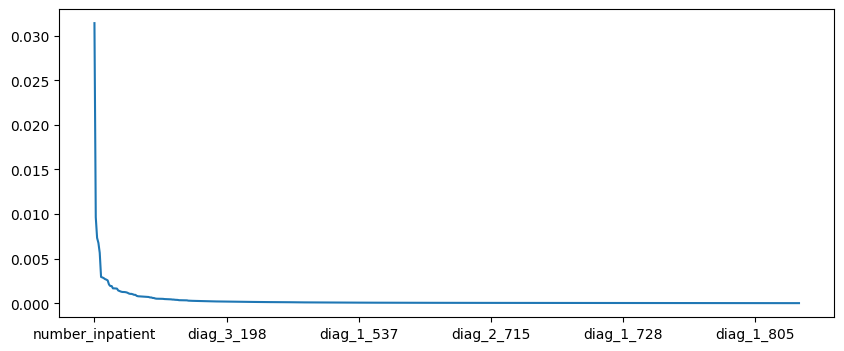

In [23]:
mi_scores
mi_scores.plot(kind="line", figsize=(10,4))


In [24]:
good_cols = mi_scores[mi_scores > 0.001].index.tolist()

In [25]:
good_cols

['number_inpatient',
 'number_emergency',
 'number_diagnoses',
 'number_outpatient',
 'num_medications',
 'discharge_disposition_id_Other',
 'admission_source_id_7',
 'time_in_hospital',
 'num_lab_procedures',
 'diag_1_428',
 'discharge_disposition_id_1',
 'discharge_disposition_id_6',
 'diabetesMed_No',
 'diabetesMed_Yes',
 'diag_2_250',
 'admission_source_id_Other',
 'age',
 'medical_specialty_Other',
 'admission_type_id_3',
 'num_procedures',
 'diag_2_403',
 'insulin_Down',
 'diag_3_401',
 'diag_3_250',
 'insulin_No',
 'is_weight_recorded',
 'diag_2_401',
 'change_No',
 'change_Ch']

# 3. Trying Some Simple Models

### Logistic Regression to provide a justification for non-linear models

### To avoid data leakage:
 - scale within each fold
 -

In [18]:
train_df = pd.read_csv("../Dataset/clean_train_df.csv")

In [ ]:
### Dropping bad cols
train_df = train_df[good_cols]

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = train_df.drop(columns=["readmitted"]) #all the input features (everything but the target which is readmitted column)
y = LabelEncoder().fit_transform(train_df["readmitted"]) #the target mapped into integers (no = 0, >30 = 1, <30 = 2)

# standardises the columns (makes them mean = 0, standard deviation = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# split the data into 5 folds, 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# linear classifier 
# class_weight balanced means to care more about the rare classes (give them a higher weight)
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

# f1 macro means f1 for each class and then averaged
scores = cross_val_score(
    log_reg,
    X_scaled,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Logistic Regression F1 (macro):", scores.mean(), "±", scores.std())

/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/sklearn/linear_model/_logisti

Logistic Regression F1 (macro): 0.4355250363292549 ± 0.0021582140083810128


## Kernel Methods

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import cross_val_score
import numpy as np

# used the following article: https://machinelearningmastery.com/kernel-methods-machine-learning-python/

# Linear SVM baseline (still linear decision boundary)
svm_linear = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)
print("svm linear done")

linear_scores = cross_val_score(
    svm_linear,
    X_scaled,
    y,
    cv=cv,
    scoring="f1_macro"
)

linear_mean = linear_scores.mean()
linear_std = linear_scores.std()

print("Linear SVM F1 (macro):", linear_scores.mean(), "±", linear_scores.std())

log_result(
    model_name="LinearSVC",
    params={
        "class_weight": "balanced",
        "max_iter": 5000
    },
    mean_score=linear_mean,
    std_score=linear_std,
    notes="Linear baseline"
)


# RBF kernel SVM (non-linear decision boundary)

#do pca before the kernel method to reduce dimensions (takes too long otherwise + we want to focus on the most important features of the data)

NUM_OF_COMPONENTS = 50
rbf_with_pca = Pipeline([
    ("pca", PCA(n_components=NUM_OF_COMPONENTS, random_state=42)),  #keep a certain number of components
    ("svm", SVC(kernel="rbf", gamma="scale", C=1.0, class_weight="balanced"))
])


rbf_scores = cross_val_score(
    rbf_with_pca,
    X_scaled,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1 #use all available cpu cores
)

rbf_mean = rbf_scores.mean()
rbf_std = rbf_scores.std()

print("RBF SVM F1 (macro):", rbf_scores.mean(), "±", rbf_scores.std())

log_result(
    model_name=f"PCA{NUM_OF_COMPONENTS}+SVC_RBF",
    params={
        "pca_n_components": NUM_OF_COMPONENTS,
        "svm_kernel": "rbf",
        "svm_gamma": "scale",
        "svm_C": 1.0,
        "class_weight": "balanced"
    },
    mean_score=rbf_mean,
    std_score=rbf_std,
    notes=f"PCA keeps {NUM_OF_COMPONENTS} components; reduces dimension automatically"
)

svm linear done
Linear SVM F1 (macro): 0.4386169822230765 ± 0.004328010740367475
✔ Logged result for LinearSVC
RBF SVM F1 (macro): 0.4291122351960328 ± 0.001953059698078017
✔ Logged result for PCA50+SVC_RBF
